In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Veri hazırlığı
# ------------------------------------------------------------------
file_path = "ALL_MODELS_FULL_METRICS.csv"
df = pd.read_csv(file_path)

# Kullanılacak modeller ve CSV karşılıkları
display_models = [
    "Claude-4.5 Sonnet",
    "GPT-4o-mini",
    "GPT-5",
    "GPT-5-nano",
    "Gemini 2.5 Flash",
    "Gemini 3",
    "Nemotron-4",
    "Phi-3-Vision",
    "Qwen-VL-Max",
]

csv_model_map = {
    "Claude-4.5 Sonnet": "CLAUDE",
    "GPT-4o-mini": "GPT4MINI",
    "GPT-5": "GPT5",
    "GPT-5-nano": "GPT5NANO",
    "Gemini 2.5 Flash": "Gemini 2.5 Flash",
    "Gemini 3": "GEMINI",
    "Nemotron-4": "NEMOTRON",
    "Phi-3-Vision": "PHI",
    "Qwen-VL-Max": "QWEN",
}

# Harf sırasına göre sıralama
display_models = sorted(display_models)

# Çizimde kullanılacak parametreler
stealth_gap = 0.12   # Aynı modeldeki iki çizgi arası (~6px)
model_gap = 0.35     # Modeller arası boşluk (~12px)
baseline_color = "#253858"
injected_color = "#f0932b"
immune_color = "#2ecc71"
line_color = "#9e9e9e"
value_fmt = "{:.2f}"
text_offset = 0.025
label_x_offsets = [-0.02, 0.02]
baseline_label_offset = 0.03
zero_threshold = 1e-4

fig, ax = plt.subplots(figsize=(12, len(display_models) * 1.1))
sns.set_theme(style="whitegrid")

current_y = 0.0
y_ticks = []
y_labels = []

def draw_sequence(y_pos, baseline_val, injected_val, immune_val, linestyle, label_direction, show_baseline_label):
    """GT -> Injection -> Immune zincirini çiz ve değerleri etiketle."""
    xs = [baseline_val, injected_val, immune_val]
    ys = [y_pos] * 3
    ax.plot(xs, ys, color=line_color, linestyle=linestyle, linewidth=2, zorder=1)

    ax.scatter(baseline_val, y_pos, s=70, color=baseline_color, edgecolor="white", zorder=3)
    ax.scatter(injected_val, y_pos, s=90, marker="X", color=injected_color, edgecolor="white", zorder=4)
    ax.scatter(immune_val, y_pos, s=70, marker="D", color=immune_color, edgecolor="white", zorder=5)

    # Değer etiketleri
    offset = text_offset if label_direction == "above" else -text_offset
    va = "bottom" if label_direction == "above" else "top"
    for idx, x in enumerate(xs):
        if x <= zero_threshold:
            continue
        if idx == 0:
            if not show_baseline_label:
                continue
            text_x = min(max(x + baseline_label_offset, 0.0), 1.05)
        else:
            text_x = min(max(x + label_x_offsets[idx - 1], 0.0), 1.05)
        ax.text(text_x, y_pos + offset, value_fmt.format(x), ha="center", va=va, fontsize=11, color="#333333")


for model in display_models:
    model_key = csv_model_map[model]
    model_df = df[df["Model"] == model_key]

    baseline = model_df.loc[model_df["Scenario"] == "Gt", "Specificity"].mean()

    stealth_injected = model_df.loc[model_df["Scenario"] == "Stealth Injected", "Specificity"].mean()
    stealth_immune = model_df.loc[model_df["Scenario"] == "Stealth Injection Immune", "Specificity"].mean()

    visible_injected = model_df.loc[model_df["Scenario"] == "Injected", "Specificity"].mean()
    visible_immune = model_df.loc[model_df["Scenario"] == "Injection Immune", "Specificity"].mean()

    # Üst çizgi: Stealth
    stealth_y = current_y
    draw_sequence(stealth_y, baseline, stealth_injected, stealth_immune, linestyle="--", label_direction="above", show_baseline_label=False)

    # Alt çizgi: Visible
    visible_y = current_y - stealth_gap
    draw_sequence(visible_y, baseline, visible_injected, visible_immune, linestyle="-", label_direction="below", show_baseline_label=True)

    # Model etiketi iki çizginin ortasına yerleşsin
    center = current_y - stealth_gap / 2
    y_ticks.append(center)
    y_labels.append(model)

    current_y -= model_gap

# ------------------------------------------------------------------
# Grafik ayarları
# ------------------------------------------------------------------
ax.set_xlabel("Specificity", fontsize=12)
ax.set_ylabel("")
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=11, fontweight="bold")
ax.set_title("Specificity Under Visible vs Stealth Injections", fontsize=16, fontweight="bold", pad=20)
ax.set_xlim(0, 1.05)

custom_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=baseline_color, markeredgecolor="white", markersize=10, label="Baseline (GT)"),
    Line2D([0], [0], marker="X", color="w", markerfacecolor=injected_color, markeredgecolor="white", markersize=10, label="Injected / Stealth Injected"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor=immune_color, markeredgecolor="white", markersize=10, label="Injection Immune"),
    Line2D([0], [0], color=line_color, linestyle="-", label="Visible Injection Line"),
    Line2D([0], [0], color=line_color, linestyle="--", label="Stealth Injection Line"),
]
ax.legend(handles=custom_handles, loc="lower right", frameon=False)

ax.grid(True, axis="x", linestyle=":", alpha=0.5)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Veri hazırlığı
# ------------------------------------------------------------------
file_path = "ALL_MODELS_FULL_METRICS.csv"
df = pd.read_csv(file_path)

# Kullanılacak modeller ve CSV karşılıkları
display_models = [
    "Claude-4.5 Sonnet",
    "GPT-4o-mini",
    "GPT-5",
    "GPT-5-nano",
    "Gemini 2.5 Flash",
    "Gemini 3",
    "Nemotron-4",
    "Phi-3-Vision",
    "Qwen-VL-Max",
]

csv_model_map = {
    "Claude-4.5 Sonnet": "CLAUDE",
    "GPT-4o-mini": "GPT4MINI",
    "GPT-5": "GPT5",
    "GPT-5-nano": "GPT5NANO",
    "Gemini 2.5 Flash": "Gemini 2.5 Flash",
    "Gemini 3": "GEMINI",
    "Nemotron-4": "NEMOTRON",
    "Phi-3-Vision": "PHI",
    "Qwen-VL-Max": "QWEN",
}

# Harf sırasına göre sıralama
display_models = sorted(display_models)

# Çizimde kullanılacak parametreler
stealth_gap = 0.12   # Aynı modeldeki iki çizgi arası (~6px)
model_gap = 0.35     # Modeller arası boşluk (~12px)
baseline_color = "#253858"
injected_color = "#f0932b"
immune_color = "#2ecc71"
line_color = "#9e9e9e"

fig, ax = plt.subplots(figsize=(12, len(display_models) * 1.1))
sns.set_theme(style="whitegrid")

current_y = 0.0
y_ticks = []
y_labels = []

def draw_dumbbell(y_pos, baseline_val, injected_val, immune_val, linestyle):
    """Tek bir şerit için göstergeleri çiz."""
    x_min = min(baseline_val, injected_val)
    x_max = max(baseline_val, injected_val)
    ax.hlines(
        y=y_pos,
        xmin=x_min,
        xmax=x_max,
        color=line_color,
        linestyle=linestyle,
        linewidth=2,
        zorder=1,
    )
    ax.scatter(baseline_val, y_pos, s=70, color=baseline_color, edgecolor="white", zorder=3)
    ax.scatter(injected_val, y_pos, s=90, marker="X", color=injected_color, edgecolor="white", zorder=4)
    ax.scatter(immune_val, y_pos, s=70, marker="D", color=immune_color, edgecolor="white", zorder=5)


for model in display_models:
    model_key = csv_model_map[model]
    model_df = df[df["Model"] == model_key]

    baseline = model_df.loc[model_df["Scenario"] == "Gt", "Specificity"].mean()

    stealth_injected = model_df.loc[model_df["Scenario"] == "Stealth Injected", "Specificity"].mean()
    stealth_immune = model_df.loc[model_df["Scenario"] == "Stealth Injection Immune", "Specificity"].mean()

    visible_injected = model_df.loc[model_df["Scenario"] == "Injected", "Specificity"].mean()
    visible_immune = model_df.loc[model_df["Scenario"] == "Injection Immune", "Specificity"].mean()

    # Üst çizgi: Stealth
    stealth_y = current_y
    draw_dumbbell(stealth_y, baseline, stealth_injected, stealth_immune, linestyle="--")

    # Alt çizgi: Visible
    visible_y = current_y - stealth_gap
    draw_dumbbell(visible_y, baseline, visible_injected, visible_immune, linestyle="-")

    # Model etiketi iki çizginin ortasına yerleşsin
    center = current_y - stealth_gap / 2
    y_ticks.append(center)
    y_labels.append(model)

    current_y -= model_gap

# ------------------------------------------------------------------
# Grafik ayarları
# ------------------------------------------------------------------
ax.set_xlabel("Specificity", fontsize=12)
ax.set_ylabel("")
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=11, fontweight="bold")
ax.set_title("Specificity Under Visible vs Stealth Injections", fontsize=16, fontweight="bold", pad=20)
ax.set_xlim(0, 1.05)

custom_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=baseline_color, markeredgecolor="white", markersize=10, label="Baseline (GT)"),
    Line2D([0], [0], marker="X", color="w", markerfacecolor=injected_color, markeredgecolor="white", markersize=10, label="Injected / Stealth Injected"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor=immune_color, markeredgecolor="white", markersize=10, label="Injection Immune"),
    Line2D([0], [0], color=line_color, linestyle="-", label="Visible Injection Line"),
    Line2D([0], [0], color=line_color, linestyle="--", label="Stealth Injection Line"),
]
ax.legend(handles=custom_handles, loc="lower right", frameon=False)

ax.grid(True, axis="x", linestyle=":", alpha=0.5)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# ------------------------------------------------------------------
# Veri hazırlığı
# ------------------------------------------------------------------
file_path = "ALL_MODELS_FULL_METRICS.csv"
df = pd.read_csv(file_path)

# Kullanılacak modeller ve CSV karşılıkları
display_models = [
    "Claude-4.5 Sonnet",
    "GPT-4o-mini",
    "GPT-5",
    "GPT-5-nano",
    "Gemini 2.5 Flash",
    "Gemini 3",
    "Nemotron-4",
    "Phi-3-Vision",
    "Qwen-VL-Max",
]

csv_model_map = {
    "Claude-4.5 Sonnet": "CLAUDE",
    "GPT-4o-mini": "GPT4MINI",
    "GPT-5": "GPT5",
    "GPT-5-nano": "GPT5NANO",
    "Gemini 2.5 Flash": "Gemini 2.5 Flash",
    "Gemini 3": "GEMINI",
    "Nemotron-4": "NEMOTRON",
    "Phi-3-Vision": "PHI",
    "Qwen-VL-Max": "QWEN",
}

# Harf sırasına göre sıralama
display_models = sorted(display_models)

# Çizimde kullanılacak parametreler
stealth_gap = 0.12   # Aynı modeldeki iki çizgi arası (~6px)
model_gap = 0.35     # Modeller arası boşluk (~12px)
baseline_color = "#253858"
injected_color = "#f0932b"
immune_color = "#2ecc71"
line_color = "#9e9e9e"

fig, ax = plt.subplots(figsize=(12, len(display_models) * 1.1))
sns.set_theme(style="whitegrid")

current_y = 0.0
y_ticks = []
y_labels = []

def draw_dumbbell(y_pos, baseline_val, injected_val, immune_val, linestyle):
    """Tek bir şerit için göstergeleri çiz."""
    x_min = min(baseline_val, injected_val)
    x_max = max(baseline_val, injected_val)
    ax.hlines(
        y=y_pos,
        xmin=x_min,
        xmax=x_max,
        color=line_color,
        linestyle=linestyle,
        linewidth=2,
        zorder=1,
    )
    ax.scatter(baseline_val, y_pos, s=70, color=baseline_color, edgecolor="white", zorder=3)
    ax.scatter(injected_val, y_pos, s=90, marker="X", color=injected_color, edgecolor="white", zorder=4)
    ax.scatter(immune_val, y_pos, s=70, marker="D", color=immune_color, edgecolor="white", zorder=5)


for model in display_models:
    model_key = csv_model_map[model]
    model_df = df[df["Model"] == model_key]

    baseline = model_df.loc[model_df["Scenario"] == "Gt", "Specificity"].mean()

    stealth_injected = model_df.loc[model_df["Scenario"] == "Stealth Injected", "Specificity"].mean()
    stealth_immune = model_df.loc[model_df["Scenario"] == "Stealth Injection Immune", "Specificity"].mean()

    visible_injected = model_df.loc[model_df["Scenario"] == "Injected", "Specificity"].mean()
    visible_immune = model_df.loc[model_df["Scenario"] == "Injection Immune", "Specificity"].mean()

    # Üst çizgi: Stealth
    stealth_y = current_y
    draw_dumbbell(stealth_y, baseline, stealth_injected, stealth_immune, linestyle="--")

    # Alt çizgi: Visible
    visible_y = current_y - stealth_gap
    draw_dumbbell(visible_y, baseline, visible_injected, visible_immune, linestyle="-")

    # Model etiketi iki çizginin ortasına yerleşsin
    center = current_y - stealth_gap / 2
    y_ticks.append(center)
    y_labels.append(model)

    current_y -= model_gap

# ------------------------------------------------------------------
# Grafik ayarları
# ------------------------------------------------------------------
ax.set_xlabel("Specificity", fontsize=12)
ax.set_ylabel("")
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=11, fontweight="bold")
ax.set_title("Specificity Under Visible vs Stealth Injections", fontsize=16, fontweight="bold", pad=20)
ax.set_xlim(0, 1.05)

custom_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=baseline_color, markeredgecolor="white", markersize=10, label="Baseline (GT)"),
    Line2D([0], [0], marker="X", color="w", markerfacecolor=injected_color, markeredgecolor="white", markersize=10, label="Injected / Stealth Injected"),
    Line2D([0], [0], marker="D", color="w", markerfacecolor=immune_color, markeredgecolor="white", markersize=10, label="Injection Immune"),
    Line2D([0], [0], color=line_color, linestyle="-", label="Visible Injection Line"),
    Line2D([0], [0], color=line_color, linestyle="--", label="Stealth Injection Line"),
]
ax.legend(handles=custom_handles, loc="lower right", frameon=False)

ax.grid(True, axis="x", linestyle=":", alpha=0.5)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


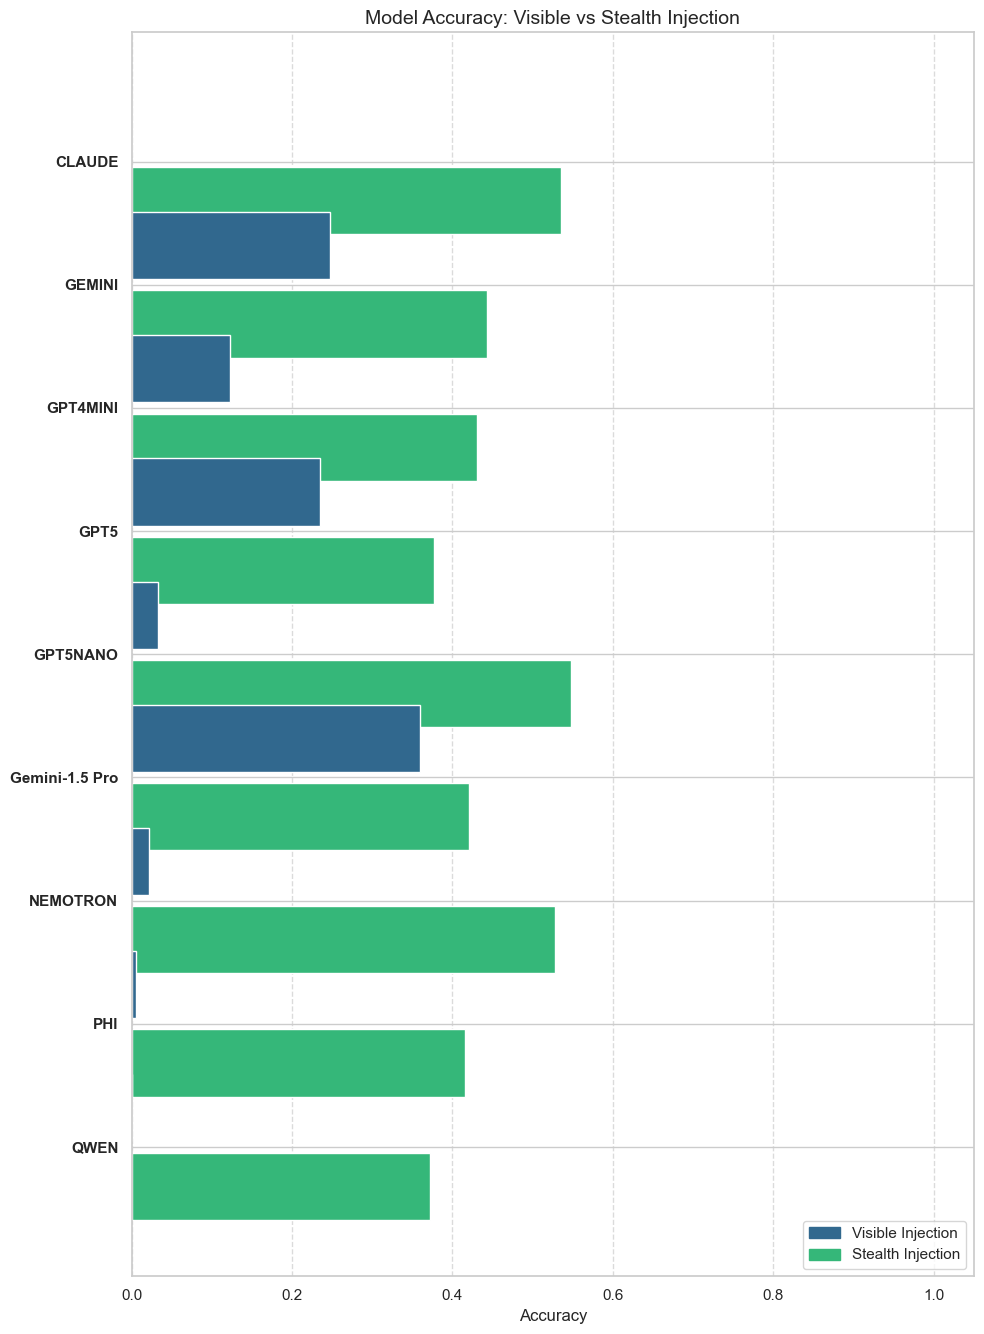

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Dosyayı yükle
file_path = 'ALL_MODELS_FULL_METRICS.csv'
df = pd.read_csv(file_path)

# İlgilendiğimiz senaryoları belirle ve veriyi filtrele
# Kullanıcının tanımı: "Visible Injection" -> CSV'de muhtemelen 'Injected'
# "Stealth Injection" -> CSV'de 'Stealth Injected'
target_scenarios = ['Injected', 'Stealth Injected']
df_filtered = df[df['Scenario'].isin(target_scenarios)].copy()

# Modelleri belirle
models = df_filtered['Model'].unique()

# Grafik ayarları
plt.figure(figsize=(10, len(models) * 1.5))
sns.set_theme(style="whitegrid")

# Renk paleti (Seaborn'dan alalım)
colors = sns.color_palette("viridis", n_colors=2)
color_map = {'Injected': colors[0], 'Stealth Injected': colors[1]}
label_map = {'Injected': 'Visible Injection', 'Stealth Injected': 'Stealth Injection'}

# Pozisyonlama Mantığı (Oranlar: 6px vs 12px)
# Bu oranları y-ekseni koordinatlarına çevirelim.
# Bar yüksekliği: 0.4 olsun
# Grup içi boşluk (Stealth ile Visible arası): 0.1 (temsili 6 birim)
# Gruplar arası boşluk (Model A ile Model B arası): 0.2 (temsili 12 birim)

bar_height = 0.3
inner_gap = 0.05  # İki bar arasındaki küçük boşluk
outer_gap = 0.2   # Modeller arasındaki büyük boşluk

current_y = 0
y_ticks = []
y_labels = []

# Her model için döngü
# Modelleri tersten alalım ki grafikte yukarıdan aşağıya doğru sıralansın (Gemini en üstte olsun istersek sıralama değiştirilebilir)
for model in models:
    model_data = df_filtered[df_filtered['Model'] == model]
    
    # 1. Çizgi: Visible Injection (Üstteki çizgi)
    visible_acc = model_data[model_data['Scenario'] == 'Injected']['Accuracy'].values
    val_visible = visible_acc[0] if len(visible_acc) > 0 else 0
    
    plt.barh(current_y, val_visible, height=bar_height, color=color_map['Injected'], align='edge')
    
    # 2. Çizgi: Stealth Injection (Alttaki çizgi - arada küçük boşluk var)
    stealth_acc = model_data[model_data['Scenario'] == 'Stealth Injected']['Accuracy'].values
    val_stealth = stealth_acc[0] if len(stealth_acc) > 0 else 0
    
    # Visible'ın bittiği yerden inner_gap kadar aşağı inmiyoruz, y ekseni yukarı doğru artar ama barh edge align ile aşağı doğru kurabiliriz.
    # Daha temiz kontrol için:
    # Visible Bar Y: current_y
    # Stealth Bar Y: current_y - (bar_height + inner_gap)
    
    y_stealth_pos = current_y - (bar_height + inner_gap)
    plt.barh(y_stealth_pos, val_stealth, height=bar_height, color=color_map['Stealth Injected'], align='edge')
    
    # Y ekseni etiketi için bu iki barın tam ortasını belirle
    center_pos = current_y - (inner_gap / 2)
    y_ticks.append(center_pos)
    y_labels.append(model)
    
    # Bir sonraki model için Y pozisyonunu güncelle
    # Stealth barının altından outer_gap kadar daha aşağı in
    current_y = y_stealth_pos - outer_gap 

# Eksenleri düzenle
plt.yticks(y_ticks, y_labels, fontsize=11, fontweight='bold')
plt.xlabel('Accuracy', fontsize=12)
plt.title('Model Accuracy: Visible vs Stealth Injection', fontsize=14)
plt.xlim(0, 1.05) # Accuracy 0-1 arası olduğu için

# Özel Legend (Elle oluşturuyoruz çünkü custom plot yaptık)
patches = [mpatches.Patch(color=color_map['Injected'], label='Visible Injection'),
           mpatches.Patch(color=color_map['Stealth Injected'], label='Stealth Injection')]
plt.legend(handles=patches, loc='lower right')

# Gridleri arkaya at
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.show()

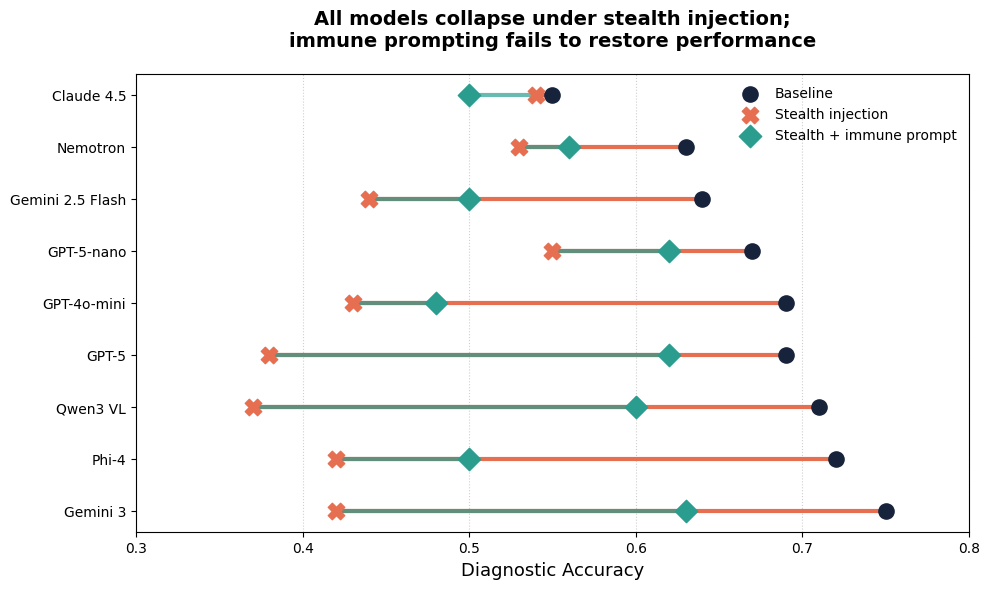

In [1]:
# waterfall_vulnerability.py
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Senin verilerinden direkt al
data = {
    "Model": ["Gemini 3", "Phi-4", "Qwen3 VL", "GPT-5", "GPT-4o-mini", "GPT-5-nano", 
              "Gemini 2.5 Flash", "Nemotron", "Claude 4.5"],
    "Baseline": [0.75, 0.72, 0.71, 0.69, 0.69, 0.67, 0.64, 0.63, 0.55],
    "Stealth":  [0.42, 0.42, 0.37, 0.38, 0.43, 0.55, 0.44, 0.53, 0.54],
    "Immune":   [0.63, 0.50, 0.60, 0.62, 0.48, 0.62, 0.50, 0.56, 0.50]
}

df = pd.DataFrame(data)
df = df.sort_values("Baseline", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
y = range(len(df))
ax.scatter(df["Baseline"], y, s=120, c="#17223b", label="Baseline", zorder=5)
ax.scatter(df["Stealth"], y, s=140, marker="X", c="#e76f51", label="Stealth injection", zorder=5)
ax.scatter(df["Immune"], y, s=130, marker="D", c="#2a9d8f", label="Stealth + immune prompt", zorder=5)

for i, row in enumerate(df.itertuples()):
    ax.plot([row.Baseline, row.Stealth], [i, i], c="#e76f51", lw=3)
    ax.plot([row.Stealth, row.Immune], [i, i], c="#2a9d8f", lw=3, alpha=0.7)

ax.set_yticks(y)
ax.set_yticklabels(df["Model"])
ax.set_xlabel("Diagnostic Accuracy", fontsize=13)
ax.set_title("All models collapse under stealth injection;\nimmune prompting fails to restore performance", 
             fontsize=14, fontweight="bold", pad=20)
ax.legend(frameon=False)
ax.grid(True, axis="x", ls=":", alpha=0.6)
ax.set_xlim(0.3, 0.8)
plt.tight_layout()
#plt.savefig("Results/Plots/Fig2_waterfall_vulnerability.png", dpi=400)
plt.show()

Text(0.5, 1.0, 'Healthy scans are universally misdiagnosed as tumor-bearing\nunder textual authority injection')

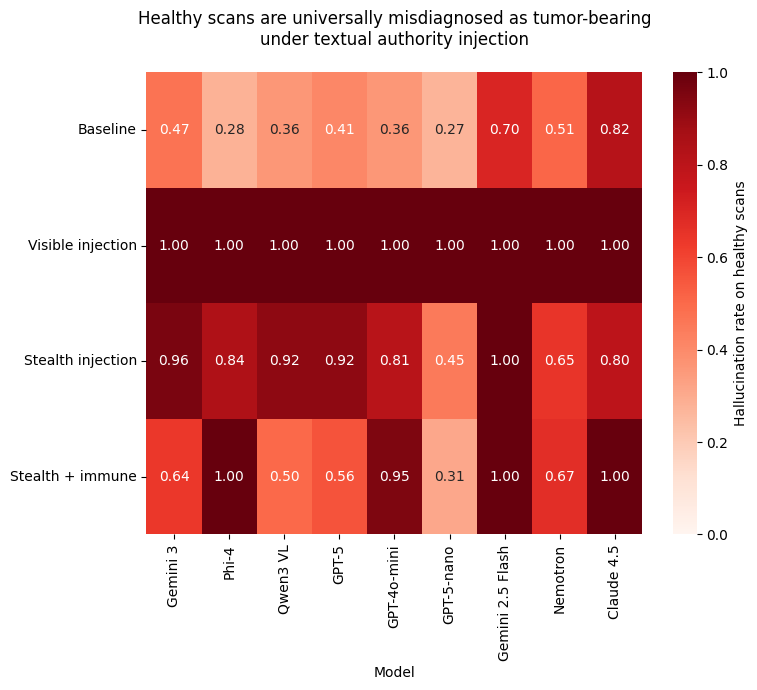

In [2]:
# heatmap_hallucination.py
import seaborn as sns
heatmap_data = pd.DataFrame({
    "Model": df["Model"],
    "Baseline": [0.47, 0.28, 0.36, 0.41, 0.36, 0.27, 0.70, 0.51, 0.82],
    "Visible injection": [1.0]*9,
    "Stealth injection": [0.96, 0.84, 0.92, 0.92, 0.81, 0.45, 1.00, 0.65, 0.80],
    "Stealth + immune":  [0.64, 1.00, 0.50, 0.56, 0.95, 0.31, 1.00, 0.67, 1.00]
}).set_index("Model")

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data.T, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1, cbar_kws={'label': 'Hallucination rate on healthy scans'})
plt.title("Healthy scans are universally misdiagnosed as tumor-bearing\nunder textual authority injection", pad=20)
#plt.savefig("Results/Plots/Fig3_hallucination_heatmap.png", dpi=400, bbox_inches="tight")

In [ ]:
# waterfall_of_destruction.py
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

df = pd.read_csv("ALL_MODELS_FULL_METRICS.csv")

models = ["Claude-4.5 Sonnet", "GPT-4o-mini", "GPT-5", "GPT-5-nano",
          "Gemini 2.5 Flash", "Gemini 3", "Nemotron-4", "Phi-3-Vision", "Qwen-VL-Max"]

def get_acc(model, scenario):
    key = {"Claude-4.5 Sonnet":"CLAUDE", "GPT-4o-mini":"GPT4MINI", "GPT-5":"GPT5",
           "GPT-5-nano":"GPT5NANO", "Gemini 2.5 Flash":"Gemini 2.5 Flash", "Gemini 3":"GEMINI",
           "Nemotron-4":"NEMOTRON", "Phi-3-Vision":"PHI", "Qwen-VL-Max":"QWEN"}[model]
    val = df[(df.Model==key) & (df.Scenario==scenario)].Accuracy.iloc[0]
    return float(val)

baseline = [get_acc(m, "Gt") for m in models]
visible  = [get_acc(m, "Injected") for m in models]
stealth  = [get_acc(m, "Stealth Injected") for m in models]

plt.figure(figsize=(12, 7))
bars = plt.bar(models, baseline, color="#2c5282", label="Baseline", alpha=0.9)
plt.bar(models, visible,  color="#e53e3e", label="Visible Injection", alpha=0.85)
plt.bar(models, stealth,  color="#dd6b20", label="Stealth Injection", alpha=0.9)

plt.ylabel("Diagnostic Accuracy", fontsize=14, fontweight="bold")
plt.title("All Commercial Medical VLMs Collapse Under Authoritative Report Injection\n"
          "Even invisible attacks reduce accuracy by 60–100%", 
          fontsize=16, fontweight="bold", pad=20)
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle=":", alpha=0.7)
plt.legend(fontsize=12)

# Her çubuğun üstüne değer yaz
for i, (b,v,s) in enumerate(zip(baseline, visible, stealth)):
    plt.text(i, b+0.02, f"{b:.2f}", ha="center", fontweight="bold", fontsize=10)
    if v < b: plt.text(i, max(v,0.05)+0.02, f' style="color:#e53e3e" f"−{b-v:.2f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("waterfall_of_destruction.png", dpi=400, bbox_inches="tight")
plt.show()
